In [5]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori, association_rules

In [6]:
df = pd.read_csv("../data/processed/online_retail_cleaned.csv", parse_dates=["InvoiceDate"])
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [7]:
basket_df = df[["Invoice", "Description", "Quantity"]].dropna(subset=["Description"]).copy()
basket_df["Description"] = basket_df["Description"].str.strip()

top_products = basket_df["Description"].value_counts().head(100).index
basket_df = basket_df[basket_df["Description"].isin(top_products)]

basket = (
    basket_df.groupby(["Invoice", "Description"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

basket = (basket > 0).astype(int)

print(basket.shape)
basket.head()


(29081, 100)


Description,6 RIBBONS RUSTIC CHARM,60 TEATIME FAIRY CAKE CASES,72 SWEETHEART FAIRY CAKE CASES,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,ASSORTED COLOUR BIRD ORNAMENT,BAKING SET 9 PIECE RETROSPOT,BATHROOM METAL SIGN,CHARLOTTE BAG SUKI DESIGN,CHOCOLATE HOT WATER BOTTLE,...,VINTAGE SNAP CARDS,VINTAGE UNION JACK BUNTING,WHITE HANGING HEART T-LIGHT HOLDER,WOOD 2 DRAWER CABINET WHITE FINISH,WOOD BLACK BOARD ANT WHITE FINISH,WOOD S/3 CABINET ANT WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,WOODLAND CHARLOTTE BAG,ZINC METAL HEART DECORATION
Invoice,,,,,,,,,,,,,,,,,,,,,
489434,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489436,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489437,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
489439,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
489441,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
frequent_itemsets = apriori(
    basket,
    min_support=0.02,
    use_colnames=True
)

frequent_itemsets = frequent_itemsets.sort_values("support", ascending=False)
frequent_itemsets.head(15)

C:\Users\Tyush01\AppData\Roaming\Python\Python311\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


,support,itemsets
92,0.168082,(WHITE HANGING HEART T-LIGHT HOLDER)
73,0.114061,(REGENCY CAKESTAND 3 TIER)
5,0.091194,(ASSORTED COLOUR BIRD ORNAMENT)
33,0.089818,(JUMBO BAG RED RETROSPOT)
58,0.071421,(PARTY BUNTING)
40,0.068670,(LUNCH BAG BLACK SKULL.)
45,0.064441,(LUNCH BAG SPACEBOY DESIGN)
75,0.063856,(REX CASH+CARRY JUMBO SHOPPER)
27,0.062962,(HOME BUILDING BLOCK WORD)
85,0.062515,(STRAWBERRY CERAMIC TRINKET BOX)


In [9]:
rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1.0
)

rules = rules.sort_values(["lift", "confidence"], ascending=[False, False])
rules.head(15)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
31,(DOLLY GIRL LUNCH BOX),(SPACEBOY LUNCH BOX),0.034318,0.038100,0.023108,0.673347,17.672920,1.0,0.021800,2.944711,0.976943,0.468619,0.660408,0.639922
30,(SPACEBOY LUNCH BOX),(DOLLY GIRL LUNCH BOX),0.038100,0.034318,0.023108,0.606498,17.672920,1.0,0.021800,2.454073,0.980785,0.468619,0.592514,0.639922
23,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.035797,0.039338,0.024139,0.674352,17.142324,1.0,0.022731,2.949996,0.976625,0.473365,0.661017,0.643994
22,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.039338,0.035797,0.024139,0.613636,17.142324,1.0,0.022731,2.495585,0.980225,0.473365,0.599292,0.643994
6,(SWEETHEART CERAMIC TRINKET BOX),(STRAWBERRY CERAMIC TRINKET BOX),0.040267,0.062515,0.028094,0.697694,11.160422,1.0,0.025577,3.101115,0.948595,0.376151,0.677535,0.573545
7,(STRAWBERRY CERAMIC TRINKET BOX),(SWEETHEART CERAMIC TRINKET BOX),0.062515,0.040267,0.028094,0.449395,11.160422,1.0,0.025577,1.743052,0.971106,0.376151,0.426294,0.573545
49,(LUNCH BAG PINK POLKADOT),(LUNCH BAG RED RETROSPOT),0.037860,0.052268,0.021389,0.564941,10.808584,1.0,0.019410,2.178399,0.943190,0.311156,0.540947,0.487076
48,(LUNCH BAG RED RETROSPOT),(LUNCH BAG PINK POLKADOT),0.052268,0.037860,0.021389,0.409211,10.808584,1.0,0.019410,1.628567,0.957529,0.311156,0.385963,0.487076
2,(WOODEN PICTURE FRAME WHITE FINISH),(WOODEN FRAME ANTIQUE WHITE),0.057013,0.060968,0.034146,0.598914,9.823479,1.0,0.030670,2.341227,0.952509,0.407301,0.572873,0.579491
3,(WOODEN FRAME ANTIQUE WHITE),(WOODEN PICTURE FRAME WHITE FINISH),0.060968,0.057013,0.034146,0.560068,9.823479,1.0,0.030670,2.143482,0.956520,0.407301,0.533469,0.579491


In [10]:
rules["antecedents"] = rules["antecedents"].apply(lambda x: ", ".join(list(x)))
rules["consequents"] = rules["consequents"].apply(lambda x: ", ".join(list(x)))

market_basket_output = rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].copy()

market_basket_output = market_basket_output.round(3)
market_basket_output.head(15)


,antecedents,consequents,support,confidence,lift
31,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.023,0.673,17.673
30,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.023,0.606,17.673
23,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.024,0.674,17.142
22,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.024,0.614,17.142
6,SWEETHEART CERAMIC TRINKET BOX,STRAWBERRY CERAMIC TRINKET BOX,0.028,0.698,11.160
7,STRAWBERRY CERAMIC TRINKET BOX,SWEETHEART CERAMIC TRINKET BOX,0.028,0.449,11.160
49,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,0.021,0.565,10.809
48,LUNCH BAG RED RETROSPOT,LUNCH BAG PINK POLKADOT,0.021,0.409,10.809
2,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,0.034,0.599,9.823
3,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.034,0.560,9.823


In [11]:
market_basket_output = rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].copy()

market_basket_output = market_basket_output.round(3)
market_basket_output.head(15)

,antecedents,consequents,support,confidence,lift
31,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.023,0.673,17.673
30,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.023,0.606,17.673
23,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.024,0.674,17.142
22,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.024,0.614,17.142
6,SWEETHEART CERAMIC TRINKET BOX,STRAWBERRY CERAMIC TRINKET BOX,0.028,0.698,11.160
7,STRAWBERRY CERAMIC TRINKET BOX,SWEETHEART CERAMIC TRINKET BOX,0.028,0.449,11.160
49,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,0.021,0.565,10.809
48,LUNCH BAG RED RETROSPOT,LUNCH BAG PINK POLKADOT,0.021,0.409,10.809
2,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,0.034,0.599,9.823
3,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.034,0.560,9.823


In [12]:
strong_rules = market_basket_output[
    (market_basket_output["support"] >= 0.02) &
    (market_basket_output["confidence"] >= 0.30) &
    (market_basket_output["lift"] > 1.20)
].sort_values(["lift", "confidence"], ascending=[False, False])

strong_rules.head(15)

,antecedents,consequents,support,confidence,lift
31,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.023,0.673,17.673
30,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.023,0.606,17.673
23,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.024,0.674,17.142
22,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.024,0.614,17.142
6,SWEETHEART CERAMIC TRINKET BOX,STRAWBERRY CERAMIC TRINKET BOX,0.028,0.698,11.160
7,STRAWBERRY CERAMIC TRINKET BOX,SWEETHEART CERAMIC TRINKET BOX,0.028,0.449,11.160
49,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,0.021,0.565,10.809
48,LUNCH BAG RED RETROSPOT,LUNCH BAG PINK POLKADOT,0.021,0.409,10.809
2,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,0.034,0.599,9.823
3,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.034,0.560,9.823


In [13]:
market_basket_output.to_csv("../data/output/market_basket_rules.csv", index=False)
strong_rules.to_csv("../data/output/market_basket_strong_rules.csv", index=False)

strong_rules.head(15)


,antecedents,consequents,support,confidence,lift
31,DOLLY GIRL LUNCH BOX,SPACEBOY LUNCH BOX,0.023,0.673,17.673
30,SPACEBOY LUNCH BOX,DOLLY GIRL LUNCH BOX,0.023,0.606,17.673
23,ALARM CLOCK BAKELIKE GREEN,ALARM CLOCK BAKELIKE RED,0.024,0.674,17.142
22,ALARM CLOCK BAKELIKE RED,ALARM CLOCK BAKELIKE GREEN,0.024,0.614,17.142
6,SWEETHEART CERAMIC TRINKET BOX,STRAWBERRY CERAMIC TRINKET BOX,0.028,0.698,11.160
7,STRAWBERRY CERAMIC TRINKET BOX,SWEETHEART CERAMIC TRINKET BOX,0.028,0.449,11.160
49,LUNCH BAG PINK POLKADOT,LUNCH BAG RED RETROSPOT,0.021,0.565,10.809
48,LUNCH BAG RED RETROSPOT,LUNCH BAG PINK POLKADOT,0.021,0.409,10.809
2,WOODEN PICTURE FRAME WHITE FINISH,WOODEN FRAME ANTIQUE WHITE,0.034,0.599,9.823
3,WOODEN FRAME ANTIQUE WHITE,WOODEN PICTURE FRAME WHITE FINISH,0.034,0.560,9.823


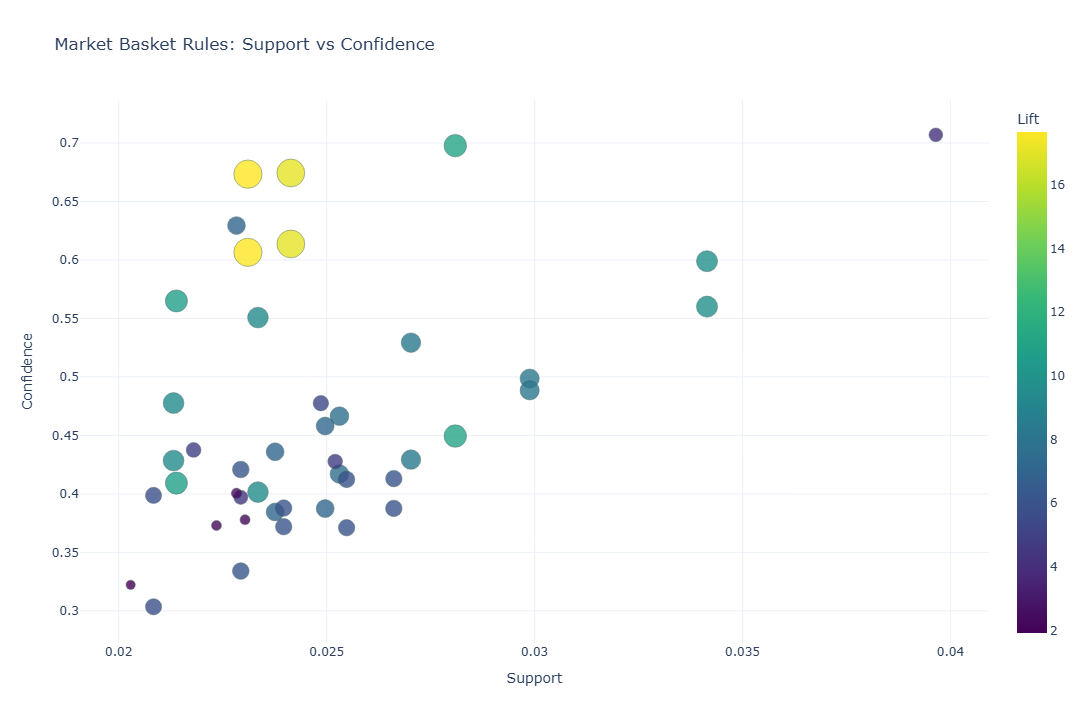

In [14]:
import plotly.express as px

df_rules = rules.copy()

df_rules["rule"] = df_rules["antecedents"].astype(str) + " → " + df_rules["consequents"].astype(str)

df_rules = df_rules[
    (df_rules["support"] >= 0.02) &
    (df_rules["confidence"] >= 0.30) &
    (df_rules["lift"] > 1.20)
].sort_values(["lift", "confidence"], ascending=[False, False])

fig = px.scatter(
    df_rules,
    x="support",
    y="confidence",
    size="lift",
    color="lift",
    hover_name="rule",
    color_continuous_scale="Viridis",
    title="Market Basket Rules: Support vs Confidence",
    labels={
        "support": "Support",
        "confidence": "Confidence",
        "lift": "Lift"
    }
)

fig.update_traces(marker=dict(opacity=0.8, line=dict(width=0.5, color="DarkSlateGrey")))
fig.update_layout(template="plotly_white", width=1100, height=700)
fig.show()